1. Solved Transform X(s):


(s**5 - 5*s**3 + 2*s**2 - 8*s - 10)/(s**6 - 7*s**5 + 3*s**4 + 11*s**3)

Solved Transform Y(s):


(-s**5 + 2*s**4 - s**3 - 2*s - 2)/(s**6 - 7*s**5 + 3*s**4 + 11*s**3)


2. Computed Solution x(t):


-5*t**2/11 - 58*t/121 + 1884*sqrt(5)*exp(4*t)*sinh(sqrt(5)*t)/6655 + 9756*exp(4*t)*cosh(sqrt(5)*t)/6655 - 354/1331 - exp(-t)/5

Computed Solution y(t):


-t**2/11 - 16*t/121 - 582*sqrt(5)*exp(4*t)*sinh(sqrt(5)*t)/1331 - 4794*exp(4*t)*cosh(sqrt(5)*t)/6655 - 106/1331 - exp(-t)/5

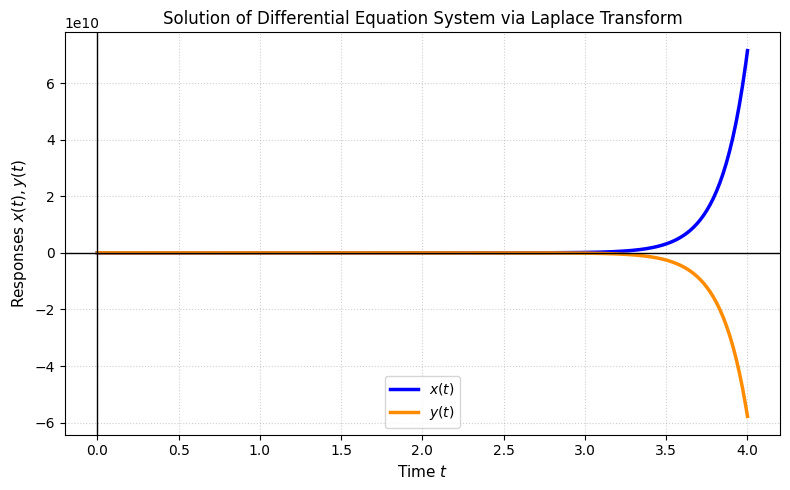

In [1]:
# Notebook: Solving a System of Differential Equations via Laplace Transform
# Example: x'(t) - 3x(t) + 4y(t) = t^2, y'(t) + x(t) - 5y(t) = e^t, with x(0) = 1, y(0) = -1

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SYMPY: Solving the Algebraic System for X(s) and Y(s) ---
s = sp.Symbol('s')
t = sp.Symbol('t', real=True, positive=True)

# Define symbolic transforms X_s and Y_s
X_s = sp.Symbol('X_s')
Y_s = sp.Symbol('Y_s')

# Equations derived from the Laplace transform of the system:
# Eq 1: (s - 3)*X_s + 4*Y_s = (s^3 + 2) / s^3
# Eq 2: X_s + (s - 5)*Y_s = -s / (s + 1)

eq1 = (s - 3)*X_s + 4*Y_s - (s**3 + 2)/s**3
eq2 = X_s + (s - 5)*Y_s - (-s/(s + 1))

# Solve the linear system for X_s and Y_s
solution = sp.solve((eq1, eq2), (X_s, Y_s))
X_s_sol = solution[X_s]
Y_s_sol = solution[Y_s]

print("1. Solved Transform X(s):")
display(X_s_sol)

print("Solved Transform Y(s):")
display(Y_s_sol)

# Compute Inverse Laplace Transforms to get x(t) and y(t)
x_t = sp.inverse_laplace_transform(X_s_sol, s, t)
y_t = sp.inverse_laplace_transform(Y_s_sol, s, t)

print("\n2. Computed Solution x(t):")
display(x_t)

print("Computed Solution y(t):")
display(y_t)


# --- 2. NUMPY & MATPLOTLIB: Time-domain response visualization ---
x_t_numeric = sp.lambdify(t, x_t, 'numpy')
y_t_numeric = sp.lambdify(t, y_t, 'numpy')

t_vals = np.linspace(0, 4, 400)
x_vals = x_t_numeric(t_vals)
y_vals = y_t_numeric(t_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_vals, x_vals, color='blue', lw=2.5, label=r'$x(t)$')
ax.plot(t_vals, y_vals, color='darkorange', lw=2.5, label=r'$y(t)$')

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel(r'Time $t$', fontsize=11)
ax.set_ylabel(r'Responses $x(t), y(t)$', fontsize=11)
ax.set_title(r'Solution of Differential Equation System via Laplace Transform', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()